In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("Video Games Sales (1980-2024) - Raw.csv")
df=pd.DataFrame(data)
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [3]:
df.shape

(64016, 13)

In [4]:
df['genre'].value_counts()

genre
Misc                9304
Action              8557
Adventure           6260
Role-Playing        5721
Sports              5586
Shooter             5410
Platform            4001
Strategy            3685
Puzzle              3521
Racing              3425
Simulation          3158
Fighting            2367
Action-Adventure    1877
Visual Novel         493
Music                297
Party                151
MMO                  115
Education             35
Board Game            33
Sandbox               20
Name: count, dtype: int64

In [5]:
df.columns

Index(['title', 'console', 'genre', 'publisher', 'developer', 'critic_score',
       'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales',
       'release_date', 'last_update'],
      dtype='object')

In [6]:
df.isnull().sum()

title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [7]:
cursor=df.groupby('genre', as_index=False)['total_sales'].sum()

In [8]:
print(cursor)

               genre  total_sales
0             Action      1125.89
1   Action-Adventure       148.52
2          Adventure       325.39
3         Board Game         0.33
4          Education         0.97
5           Fighting       341.13
6                MMO         9.31
7               Misc       557.79
8              Music        51.75
9              Party         6.21
10          Platform       349.15
11            Puzzle       127.28
12            Racing       525.75
13      Role-Playing       426.80
14           Sandbox         1.89
15           Shooter       995.50
16        Simulation       300.65
17            Sports      1187.51
18          Strategy       118.31
19      Visual Novel         5.78


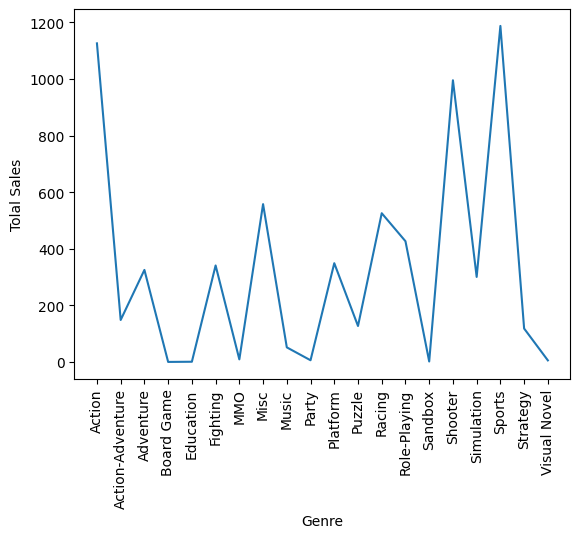

In [10]:
plt.plot(cursor['genre'],cursor['total_sales'])
plt.xticks(rotation=90);
plt.xlabel("Genre");
plt.ylabel("Tolal Sales");

## Top 10 highest selling games 

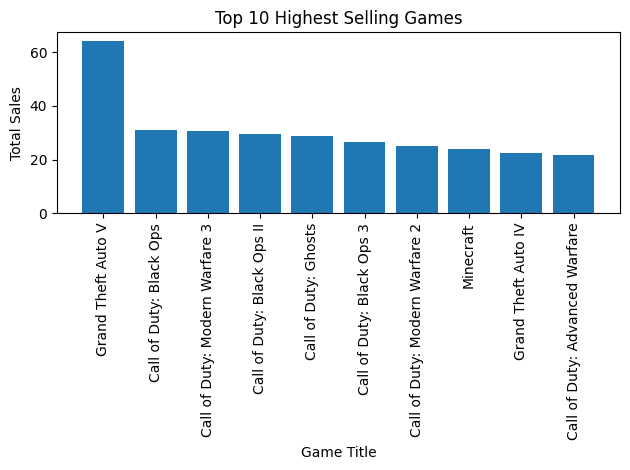

In [46]:


top_games = df.groupby('title', as_index=False)['total_sales'] \
              .sum() \
              .sort_values(by='total_sales', ascending=False) \
              .head(10)


plt.bar(top_games['title'], top_games['total_sales'])
plt.xticks(rotation=90)
plt.title("Top 10 Highest Selling Games")
plt.xlabel("Game Title")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

3. Regional Popularity

Analyze which region (NA, JP, PAL, Other) contributes the most to total sales overall.

In [30]:
df[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']]

,na_sales,jp_sales,pal_sales,other_sales
0,6.37,0.99,9.85,3.12
1,6.06,0.60,9.71,3.02
2,8.41,0.47,5.49,1.78
3,9.06,0.06,5.33,1.42
4,6.18,0.41,6.05,2.44
...,...,...,...,...
64011,NaN,NaN,NaN,NaN
64012,NaN,NaN,NaN,NaN
64013,NaN,NaN,NaN,NaN
64014,NaN,NaN,NaN,NaN


4. Publisher Performance

Determine the top 5 publishers based on total global sales.

In [35]:
top5publisher=df.groupby('publisher',as_index=False)['total_sales'].sum().sort_values(by='total_sales',ascending=False).head()
top5publisher

,publisher,total_sales
101,Activision,722.77
852,Electronic Arts,644.13
813,EA Sports,485.66
3043,Ubisoft,462.57
2818,THQ,320.89


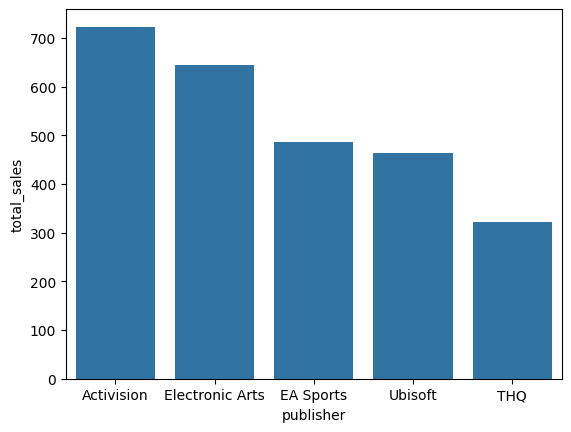

In [42]:
sns.barplot(x=top5publisher['publisher'],y=top5publisher['total_sales'])
plt.xlabel('publisher');
plt.ylabel('total_sales');

5. Critic Score vs Sales

Text(0, 0.5, 'Total Sales')

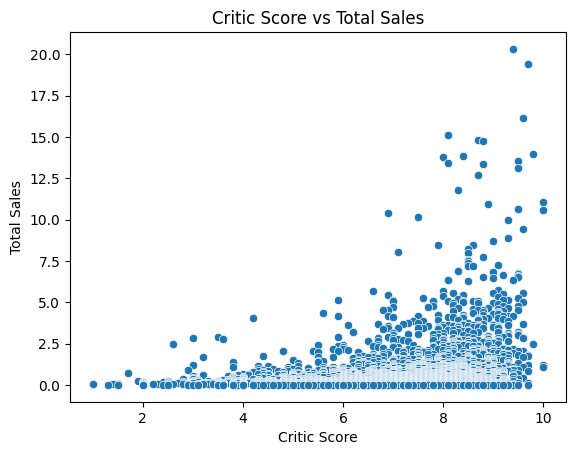

In [39]:
sns.scatterplot(x=df['critic_score'],y=df['total_sales'])
plt.title("Critic Score vs Total Sales")
plt.xlabel("Critic Score")
plt.ylabel("Total Sales")

✅ 6. Console-wise Sales

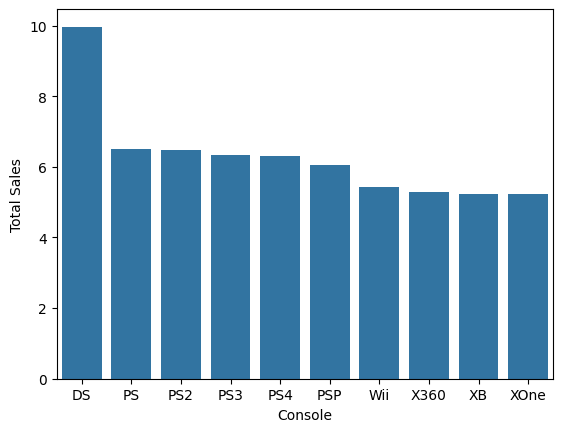

In [49]:
top_console = df.groupby('console', as_index=False)['total_sales'] \
              .sum() \
              .sort_values(by='total_sales', ascending=False) \
              .head(10)
sns.barplot(x=top_console['console'],y=df['total_sales'])
plt.xlabel('Console');
plt.ylabel('Total Sales');

7. Year-wise Sales Trend

In [50]:
df.columns

Index(['title', 'console', 'genre', 'publisher', 'developer', 'critic_score',
       'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales',
       'release_date', 'last_update'],
      dtype='object')

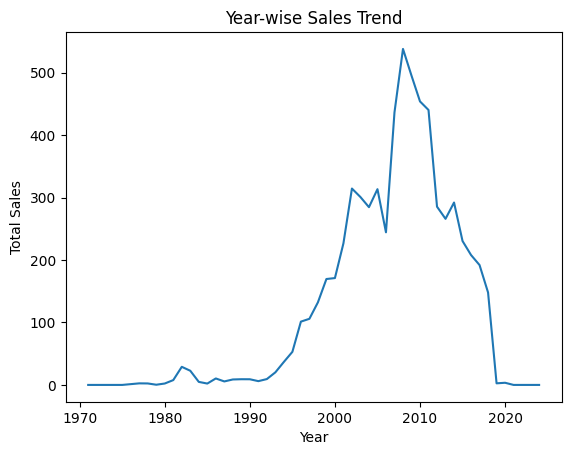

In [53]:
df['release_date'] = pd.to_datetime(df['release_date'], format='%d-%m-%Y', errors='coerce')

yearly_sales = df.groupby(df['release_date'].dt.year)['total_sales'].sum()

plt.figure()
yearly_sales.plot()
plt.title("Year-wise Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

top developers

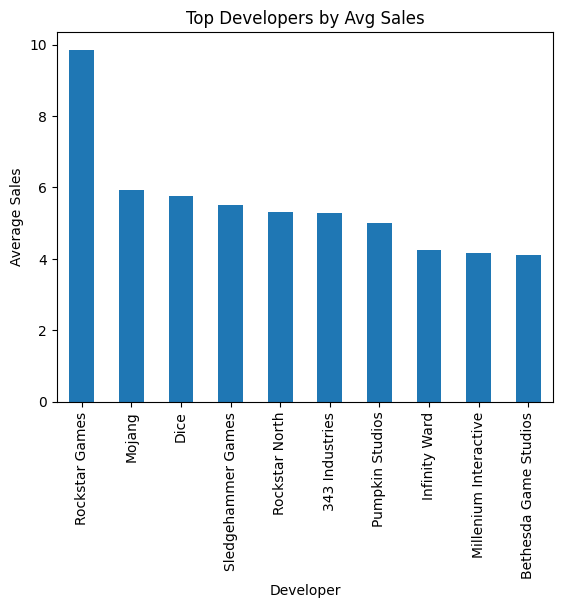

In [56]:
developer_avg = df.groupby('developer')['total_sales'].mean().sort_values(ascending=False).head(10)

plt.figure()
developer_avg.plot(kind='bar')
plt.title("Top Developers by Avg Sales")
plt.xlabel("Developer")
plt.ylabel("Average Sales")
plt.xticks(rotation=90)
plt.show()

games vs publisher

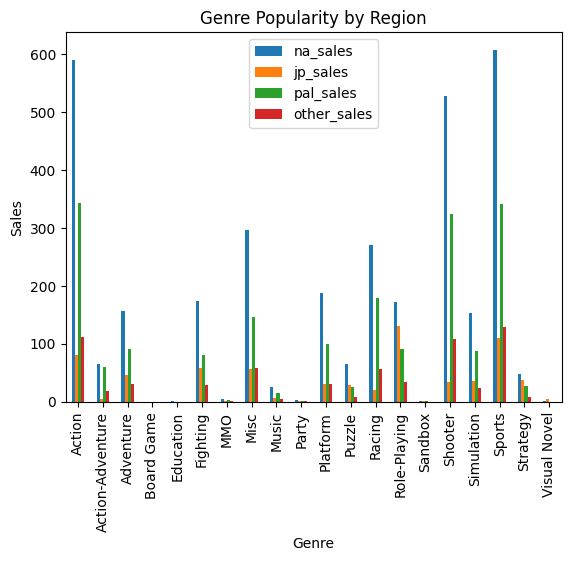

In [76]:
genre_region = df.groupby('genre')[['na_sales','jp_sales','pal_sales','other_sales']].sum()

genre_region.plot(kind='bar')
plt.title("Genre Popularity by Region")
plt.xlabel("Genre")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()